In [133]:
import os

from msmjax.kernels import split_one_over_r
from tests.test_shortrange import fixture_dir_structures

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

from functools import partial

import numpy as onp
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from msmjax.kernels import split_one_over_r, SoftenerOneOverR
from msmjax.bspline.gridops import (
    set_up_grids_all_levels,
    create_all_grid_to_grid_ops,
)
from msmjax.core.shortrange import make_eval_pair_pot
from msmjax.kernels import make_construct_stencils
from msmjax.utils.benchmarking import plot_parity_line
from msmjax.core.longrange import make_compute_u_oneplus, make_grid_pass_fn
from msmjax.bspline.gridops import make_basis_evaluation_fn
from msmjax.core.shortrange import _gen_supercell

In [2]:
TOL = 5.0e-6

# Particle config

In [32]:
side_lengths = onp.array([2.0, 8.0])
# Corresponding to a particle density of 1.0:
n_particles = int(onp.prod(side_lengths))
n_dim = len(side_lengths)

# rng = onp.random.default_rng(283)
# rng = onp.random.default_rng(2839)
rng = onp.random.default_rng(1378)
positions = rng.uniform(0.0, side_lengths, size=(n_particles, n_dim))
# In these tests, the charges don't need to sum to zero, even in the
# periodic case, and it makes for a slightly stronger test if they don't.
charges = rng.uniform(-1.0, 1.0, size=n_particles)

cell = onp.diag(side_lengths)

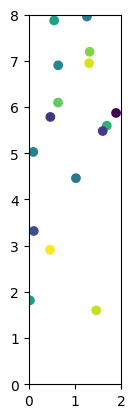

In [33]:
fig, ax = plt.subplots()
ax.set_aspect("equal")
ax.set_xlim(0, side_lengths[0])
ax.set_ylim(0, side_lengths[1])
ax.scatter(positions[:, 0], positions[:, 1], c=charges)
plt.show()

In [34]:
PBC = (True, True)
LEVEL_ZERO_CUTOFF = 2.0
LEVEL_ONE_SPACINGS = onp.array([1.0, 0.5])
MAX_LEVEL_SPLIT = 4
P = 4

kernel_fns = split_one_over_r(
    max_level=MAX_LEVEL_SPLIT,
    level_zero_cutoff=LEVEL_ZERO_CUTOFF,
    softening_function=SoftenerOneOverR(P),
)

max_level_eval = MAX_LEVEL_SPLIT - 1
kernel_fns = kernel_fns[: max_level_eval + 1]

In [35]:
cutoffs_all_levels = 2 ** (onp.arange(max_level_eval + 1)) * LEVEL_ZERO_CUTOFF
cutoffs_all_levels

array([ 2.,  4.,  8., 16.])

In [36]:
shapes_all_levels, spacings_all_levels = set_up_grids_all_levels(
    side_lengths=side_lengths,
    level_one_spacings=LEVEL_ONE_SPACINGS,
    pbc=PBC,
    max_grid_level=max_level_eval,
    p=P,
)
print(shapes_all_levels)
print(spacings_all_levels)

[None, (2, 16), (1, 8), (1, 4)]
[None, array([1. , 0.5]), array([2., 1.]), array([4., 2.])]


In [37]:
from msmjax.kernels import (
    make_construct_stencils,
)
from msmjax.utils.general import find_covering_grid_extents
from msmjax.bspline.coefficients import compute_coeffs_with_truncation
from msmjax.bspline.gridops import create_all_grid_to_grid_ops

alpha = (LEVEL_ZERO_CUTOFF / LEVEL_ONE_SPACINGS).max()
mu = max(int(4 * alpha + P // 2), 3 * P // 2)
omega, _ = compute_coeffs_with_truncation(P, mu)

extents_intermed = find_covering_grid_extents(cell, LEVEL_ONE_SPACINGS,
                                              2 * LEVEL_ZERO_CUTOFF)

construct_stencils = make_construct_stencils(
    omega=omega,
    n_levels_intermed=max_level_eval,
    include_toplevel=False,
    scaled_spacings=LEVEL_ONE_SPACINGS / side_lengths,
    cell_mode="ortho",
    k_lowest_intermed=kernel_fns[1],
    extents_from_center_intermed=extents_intermed,
)
stencils = construct_stencils(cell)

In [38]:
len(stencils)

4

In [39]:
basis_eval_fn = partial(
    make_basis_evaluation_fn(grid_shape=shapes_all_levels[1], p=P, pbc=PBC),
    spacings=LEVEL_ONE_SPACINGS,
)
restriction_fns, prolongation_fns, convolution_fns = (
    create_all_grid_to_grid_ops(
        grid_shapes=shapes_all_levels,
        p=P,
        pbc=PBC,
        convolution_methods=["scipy-fft"] * len(stencils),
    )
)
grid_pass_fn = make_grid_pass_fn(
    restriction_fns, prolongation_fns, convolution_fns
)


def make_calc_grid(lvl):
    stncls = [None if s is None else jnp.zeros_like(s) for s in stencils]
    stncls[lvl] = stencils[lvl].copy()
    calc_e = make_compute_u_oneplus(
        singleparticle_basis_fn_lvl_one=basis_eval_fn,
        grid_pass_fn=grid_pass_fn,
        grid_shape_lvl_one=shapes_all_levels[1],
        kernel_stencils=stncls,
    )

    def calc_f(positions, charges, cell):
        return -jax.grad(calc_e)(positions, charges, cell)

    return jax.jit(calc_e), jax.jit(calc_f)

In [40]:
supercell_diag = onp.ceil((2 * max(cutoffs_all_levels)) / side_lengths).astype(
    int
)
assert onp.all(
    max(cutoffs_all_levels) <= 0.5 * (supercell_diag * side_lengths) + TOL
)


def make_calc_direct(lvl):
    calc_e = make_eval_pair_pot(
        kernel_fns[lvl],
        pbc=PBC,
        cell_mode="ortho",
        supercell_diag=supercell_diag,
    )

    def calc_f(positions, charges, cell):
        return -jax.grad(calc_e)(positions, charges, cell)

    return jax.jit(calc_e), jax.jit(calc_f)

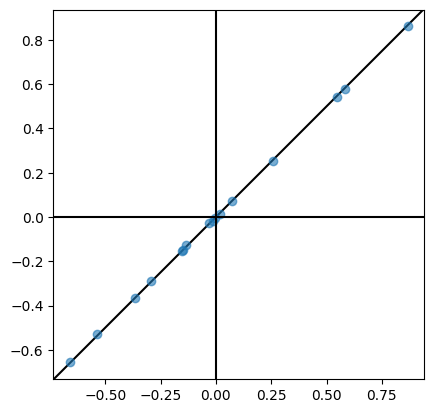

In [51]:
lvl = 1
# lvl = 2
# lvl = 3

calc_e_direct, calc_f_direct = make_calc_direct(lvl=lvl)
f_direct = calc_f_direct(positions, charges, cell=cell)

calc_e_grid, calc_f_grid = make_calc_grid(lvl=lvl)
f_grid = calc_f_grid(positions, charges, cell=None)

fig, ax = plt.subplots()
ax.set_aspect("equal")
ax.axhline(0, color="black")
ax.axvline(0, color="black")
# ax.scatter(f_direct, f_grid, alpha=0.6)
# ax.scatter(f_direct[:, 0], f_grid[:, 0], alpha=0.6)
ax.scatter(f_direct[:, 1], f_grid[:, 1], alpha=0.6)
plot_parity_line(ax, color="black", zorder=-10)
plt.show()

In [42]:
onp.linalg.norm(onp.abs(f_direct - f_grid), axis=1).max()

0.021140424783982145

In [45]:
shapes_all_levels

[None, (2, 16), (1, 8), (1, 4)]

In [52]:
from msmjax.core.longrange import _anterpolate

basis_vals, basis_inds = jax.jit(jax.vmap(basis_eval_fn))(positions)
gridcharge_lvl_one = _anterpolate(
    basis_vals, basis_inds, charges, shapes_all_levels[1]
)

In [54]:
restriction_fns

[None,
 None,
 <function msmjax.bspline.gridops.make_restriction_operator.<locals>.restrict(in_array_fine)>,
 <function msmjax.bspline.gridops.make_restriction_operator.<locals>.restrict(in_array_fine)>]

In [60]:
gridcharges_all_levels = [None]
gridcharges_all_levels.append(gridcharge_lvl_one)

# Go up ladder
for lvl in range(2, len(restriction_fns)):
    print(lvl)
    restrict = restriction_fns[lvl]
    gridcharge_fine = gridcharges_all_levels[lvl - 1]
    gridcharge_coarse = restrict(gridcharge_fine)
    gridcharges_all_levels.append(gridcharge_coarse)

2
3


In [63]:
shapes_all_levels

[None, (2, 16), (1, 8), (1, 4)]

In [66]:
[None if g is None else g.shape for g in gridcharges_all_levels]

[None, (2, 16), (1, 8), (1, 4)]

In [67]:
[None if g is None else g.sum() for g in gridcharges_all_levels]

[None,
 Array(0.8089828, dtype=float64),
 Array(0.8089828, dtype=float64),
 Array(1.6179656, dtype=float64)]

In [70]:
prolongation_fns[-2](gridcharges_all_levels[-1]).sum()

Array(3.2359312, dtype=float64)

In [71]:
prolongation_fns[-3](gridcharges_all_levels[-2]).sum()

Array(3.2359312, dtype=float64)

In [77]:
prolongation_fns

[None,
 <function msmjax.bspline.gridops.make_prolongation_operator.<locals>.prolongate(in_array_coarse)>,
 <function msmjax.bspline.gridops.make_prolongation_operator.<locals>.prolongate(in_array_coarse)>,
 None]

In [78]:
shape_coarse = shapes_all_levels[-1]
shape_fine = shapes_all_levels[-2]

In [81]:
onp.prod([s_f / s_c for s_f, s_c in zip(shape_fine, shape_coarse)])

2.0

In [83]:
(onp.array(shape_fine) / onp.array(shape_coarse)).prod()

2.0

In [90]:
for lvl in range(len(restriction_fns) - 2, 0, -1):
    lvl_in = lvl + 1
    lvl_out = lvl
    print(f"{lvl_in} -> {lvl_out}")
    input_coarse = gridcharges_all_levels[lvl_in]
    output_fine = prolongation_fns[lvl_out](input_coarse)
    print(output_fine.sum() / input_coarse.sum())

3 -> 2
2.0
2 -> 1
4.000000000000001


# Compute grid charge by direct anterpolation after maximum grid size reduction has been reached

In [92]:
basis_eval_fn_highest_level = partial(
    make_basis_evaluation_fn(grid_shape=shapes_all_levels[-1], p=P, pbc=PBC),
    spacings=spacings_all_levels[-1],
)

In [134]:
# TODO: The integer cast might not be 100% robust
spacings_to_sidelengths = (spacings_all_levels[-1] / side_lengths).astype(int)
n_repeats = onp.where(spacings_to_sidelengths > 0, spacings_to_sidelengths, 1)
positions_repeated, charges_repeated, cell_repeated = _gen_supercell(
    positions, charges, cell, supercell_diag=n_repeats
)

basis_vals, basis_inds = jax.jit(jax.vmap(basis_eval_fn_highest_level))(
    positions_repeated
)
gridcharge_highest_level = _anterpolate(
    basis_vals, basis_inds, charges_repeated, shapes_all_levels[-1]
)

In [135]:
assert onp.allclose(
    gridcharge_highest_level, gridcharges_all_levels[-1], atol=TOL
)